In [159]:
# imports
import numpy as np
import matplotlib.pyplot as plt

Problem Statement:
- The training dataset four features (size, bedrooms, floors and, age)
- Below is an example


| Size (sqft) | Number of Bedrooms  | Number of floors | Age of  Home | Price (1000s dollars)  |   
| ----------------| ------------------- |----------------- |--------------|-------------- |  
| 2104            | 5                   | 1                | 45           | 460           |  
| 1416            | 3                   | 2                | 40           | 232           |  
| 852             | 2                   | 1                | 35           | 178           | 

In [160]:
def generate_data(
    n_samples: int,
    rng: np.random.Generator,
) -> tuple[np.ndarray, np.ndarray]:
    """Generate house features and prices in thousands of dollars."""
    size = rng.integers(500, 4001, size=n_samples)
    bedrooms = rng.integers(1, 7, size=n_samples)
    floors = rng.integers(1, 4, size=n_samples)
    age = rng.integers(0, 101, size=n_samples)

    X = np.column_stack((size, bedrooms, floors, age))

    noise = rng.normal(0, 100, size=n_samples)
    y = 50 + 0.15 * size + 10 * bedrooms + 15 * floors - age + noise

    return X, y

In [161]:
rng = np.random.default_rng(42)

# Generate the training data
X_train, y_train = generate_data(1000, rng)

# Normalize the training data using z-score normalization
X_mean = X_train.mean(axis=0)
X_std = X_train.std(axis=0)
X_train_normalized = (X_train - X_mean) / X_std

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")

X_train shape: (1000, 4)
y_train shape: (1000,)


In [162]:
# Generate the testing data.
X_test, y_test = generate_data(200, rng)

X_test_normalized = (X_test - X_mean) / X_std

print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_test shape: (200, 4)
y_test shape: (200,)


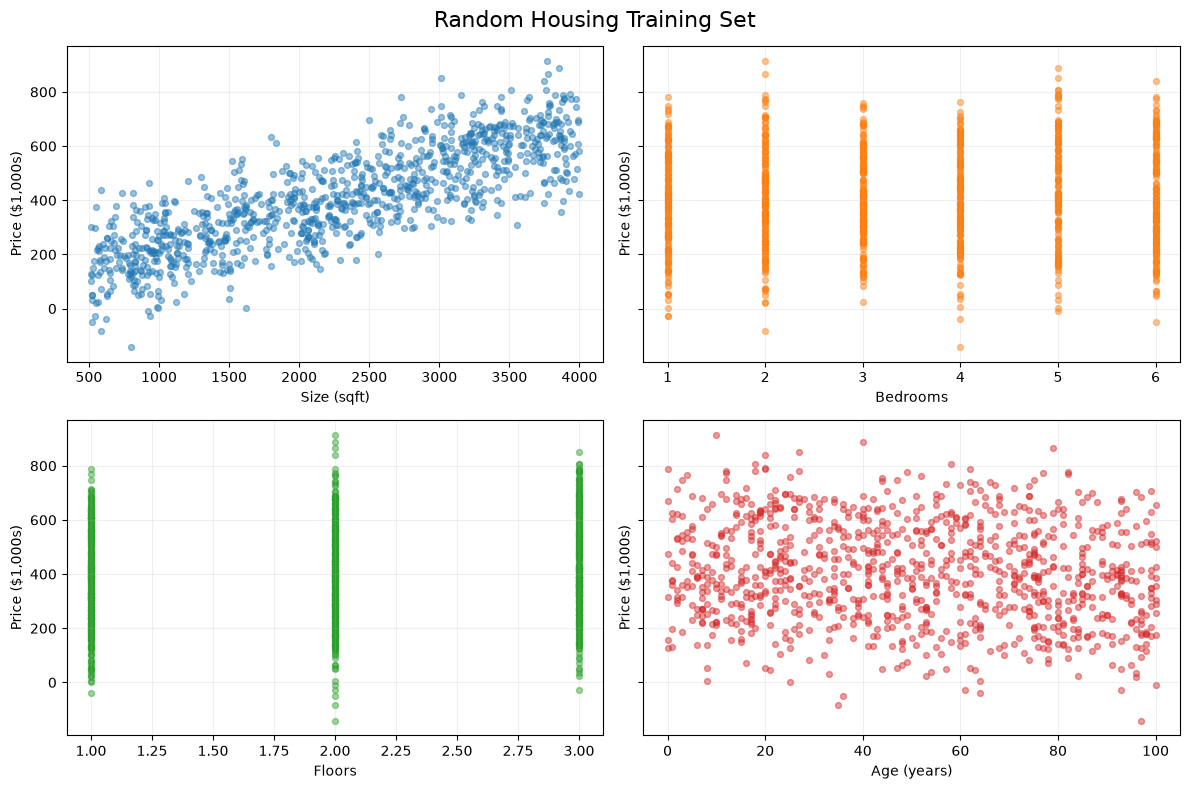

In [163]:
feature_names = ["Size (sqft)", "Bedrooms", "Floors", "Age (years)"]
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)

for feature_index, (ax, feature_name, color) in enumerate(
    zip(axes.flat, feature_names, colors)
):
    ax.scatter(
        X_train[:, feature_index],
        y_train,
        alpha=0.45,
        s=18,
        color=color,
    )
    ax.set_xlabel(feature_name)
    ax.set_ylabel("Price ($1,000s)")
    ax.grid(alpha=0.2)

fig.suptitle("Random Housing Training Set", fontsize=16)
fig.tight_layout()
plt.show()

In [164]:
def predict(x, w, b) -> float:
    """same as f_wb(x(i))"""
    prediction = np.dot(x, w) + b
    return prediction

## Gradient descent

![Gradient descent formula](img/gradient-descent.png)

In [165]:
def compute_gradient(
    X: np.ndarray,
    y: np.ndarray,
    w: np.ndarray,
    b: float,
) -> tuple[float, np.ndarray]:
    """
    Computes the gradient for linear regression
    """
    m, n = X.shape  # m examples and n features

    # One accumulated gradient for each of the n weights.
    dj_dw: np.ndarray = np.zeros(n)
    dj_db = 0.0

    for i in range(m):
        # Error for training example i: prediction - actual target.
        # X (e.g. np([1,2,3,4])) mutiply by w (e.g. np([1,2,3,4])) add b (e.g. 1)
        err: float = predict(X[i], w, b) - y[i]

        dj_dw += err * X[i]
        dj_db += err

    dj_dw /= m
    dj_db /= m

    return dj_db, dj_dw

In [166]:
def compute_cost(
    X: np.ndarray,
    y: np.ndarray,
    w: np.ndarray,
    b: float,
) -> float:
    """Return the mean squared-error cost divided by 2."""
    m = X.shape[0]
    total_cost = 0.0

    for i in range(m):
        err = predict(X[i], w, b) - y[i]
        total_cost += err**2

    return float(total_cost / (2 * m))

In [167]:
def gradient_descent(
    X: np.ndarray,
    y: np.ndarray,
    w_in: np.ndarray,
    b_in: float,
    learning_rate: float,
    num_iters: int,
) -> tuple[np.ndarray, float, list[float]]:
    """Run batch gradient descent and return w, b, and cost history."""
    w = w_in.astype(float).copy()
    b = float(b_in)
    cost_history = []

    for iteration in range(num_iters):
        # Calculate all gradients using the current w and b.
        dj_db, dj_dw = compute_gradient(X, y, w, b)

        # Update all parameters simultaneously.
        w = w - learning_rate * dj_dw
        b = b - learning_rate * dj_db

        cost = compute_cost(X, y, w, b)
        cost_history.append(cost)

        if iteration % max(1, num_iters // 10) == 0:
            print(f"Iteration {iteration}: cost = {cost:.3f}")

    return w, b, cost_history

In [168]:
initial_w = np.zeros(X_train_normalized.shape[1])
initial_b = 0.0

w_final, b_final, cost_history = gradient_descent(
    X_train_normalized,
    y_train,
    initial_w,
    initial_b,
    learning_rate=0.1,
    num_iters=500,
)

# Convert the learned parameters back to the original feature units.
w_original = w_final / X_std
b_original = b_final - np.dot(X_mean, w_original)

print(f"Weights in original units: {w_original}")
print(f"Bias in original units: {b_original:.4f}")
print(f"Final cost: {cost_history[-1]:.3f}")

Iteration 0: cost = 81313.075
Iteration 50: cost = 5035.730
Iteration 100: cost = 5033.610
Iteration 150: cost = 5033.610
Iteration 200: cost = 5033.610
Iteration 250: cost = 5033.610
Iteration 300: cost = 5033.610
Iteration 350: cost = 5033.610
Iteration 400: cost = 5033.610
Iteration 450: cost = 5033.610
Weights in original units: [ 0.14866463 10.24886065 22.070264   -0.8685578 ]
Bias in original units: 33.5333
Final cost: 5033.610


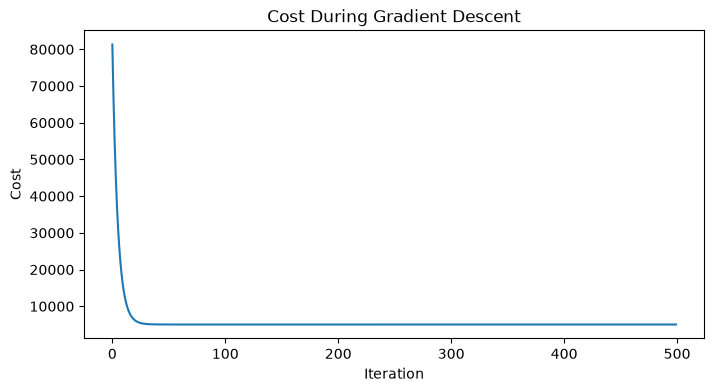

In [169]:
plt.figure(figsize=(8, 4))
plt.plot(cost_history)
plt.title("Cost During Gradient Descent")
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.grid(alpha=0.001)
plt.show()

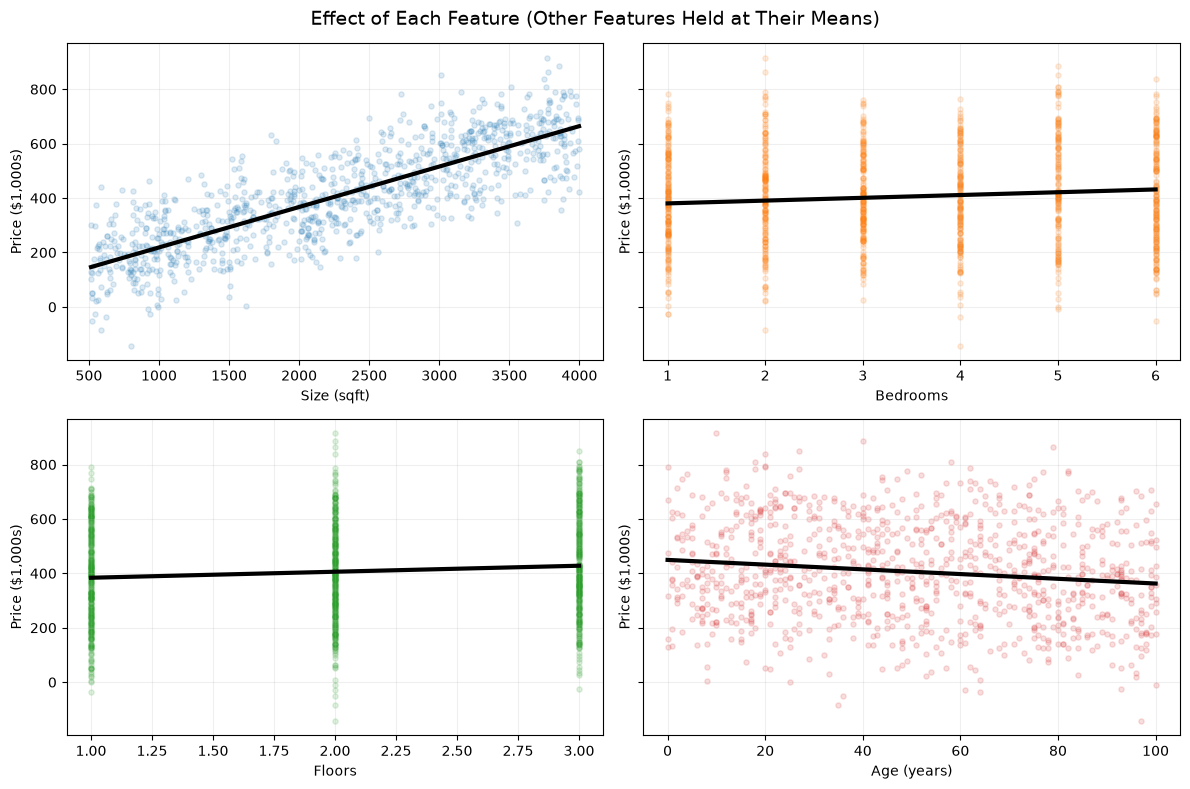

In [170]:
average_house = X_train.mean(axis=0)
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)

for j, (ax, feature_name, color) in enumerate(zip(axes.flat, feature_names, colors)):
    feature_values = np.linspace(X_train[:, j].min(), X_train[:, j].max(), 100)

    # Create 100 average houses and change only feature j.
    X_plot = np.tile(average_house, (100, 1))
    X_plot[:, j] = feature_values
    predicted_line = X_plot @ w_original + b_original

    ax.scatter(X_train[:, j], y_train, alpha=0.15, s=14, color=color)
    ax.plot(feature_values, predicted_line, color="black", linewidth=3)
    ax.set_xlabel(feature_name)
    ax.set_ylabel("Price ($1,000s)")
    ax.grid(alpha=0.2)

fig.suptitle("Effect of Each Feature (Other Features Held at Their Means)", fontsize=14)
fig.tight_layout()
plt.show()

In [171]:
y_test_pred = X_test_normalized @ w_final + b_final
test_errors = y_test_pred - y_test

# A perfect regression model scores 100%. A model that only guesses the
# average house price scores 0%.
prediction_error = np.sum(test_errors**2)
average_guess_error = np.sum((y_test - y_test.mean()) ** 2)
model_accuracy = 1 - prediction_error / average_guess_error

print(f"Model accuracy: {model_accuracy:.1%}")

Model accuracy: 71.9%
